# Fair computational-budget comparison: Adaptive Sampling vs TuRBOLFI

This notebook compares the two approximate methods on two computational axes: elapsed wall-clock time and the number of *linear utility evaluations* (one evaluation is one $x_{ij}^\top\beta$). It uses the timed Adaptive Sampling trace and the TuRBOLFI training summaries already in this repository.

The current TuRBOLFI artifacts contain posterior traces only at `early_stop` and `iter_max`. Therefore the utility-evaluation figure is a two-checkpoint TuRBOLFI frontier, while Adaptive Sampling has a continuous posterior-mean trajectory. For now, the wall-clock axis uses the saved TuRBOLFI BO/GP-loop time (`MLBA_timecost` convention), excluding its initial design and posterior MCMC; every such plot is labelled accordingly. The last cell documents what is needed for a fully end-to-end figure.

## Cost accounting used here

For Adaptive Sampling with MTM size $m$, one MCMC draw evaluates $mN$ forward and $mN$ backward auxiliary utilities, refreshes two utilities per observation, and evaluates the two-entry likelihood at the proposed parameter. Thus the recorded-work convention is $N(2m+4)$ utility evaluations per chain/draw. This is an explicit convention, not a claim about every low-level compiled operation.

For TuRBOLFI SA/MTM, a discrepancy call with $S$ simulated choice chains and $k$ MTM sweeps costs $SN[2+k(2m-1)]$: initial current utility, forward/backward MTM utilities, and observed-choice utility. The notebook additionally accounts for the 5P initial design and, when present, the stage-switch pilot/re-evaluation. GP fitting and posterior MCMC are included in wall-clock cost but do not add simulator utility evaluations.

In [1]:
from pathlib import Path
import pickle, re, sys
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Run from results/.  The paths remain valid when the notebook is opened elsewhere.
REPO = Path.cwd().resolve().parent if Path.cwd().name == 'results' else Path.cwd().resolve()
sys.path.insert(0, str(REPO / 'adaptive_sampler'))
from true_parameters import get_true_parameters

ADAPTIVE_DIR = REPO / 'results' / 'adaptive_sampler'
TURBOLFI_DIR = REPO / 'TUBOLFI' / 'final_result' / 'SA'
BUDGET_MINUTES = np.array([1, 5, 15, 60])
# Enough points for a readable frontier; never calculate RMSE at every draw.
N_FRONTIER_POINTS = 40
# Source defaults; edit only if a run used non-default MCMC settings.
ADAPTIVE_TUNE, ADAPTIVE_MTM_M = 1000, 5
TURBO_SIM_NUM, TURBO_MTM_M = 30, 5
TURBO_K_INIT, TURBO_K_WARM = 30, (20, 10)
plt.style.use('seaborn-v0_8-whitegrid')
print(f'Repository: {REPO}')

Repository: /Users/preto/Documents/EPFL/PhD/transp-or/TooManyAlternativesToHandle


In [2]:
def config_from_path(path):
    text = str(path)
    j_match, n_match, p_match = re.search(r'J(\d+)', text), re.search(r'N(\d+)(k?)', text), re.search(r'P(\d+)', text)
    if not (j_match and n_match and p_match):
        raise ValueError(f'Cannot infer J/N/P from {path}')
    N = int(n_match.group(1)) * (1000 if n_match.group(2).lower() == 'k' else 1)
    return dict(J=int(j_match.group(1)), N=N, P=int(p_match.group(1)))

def rmse_of_mean(idata, true, mask=None):
    names = [name for name in true if name in idata.posterior]
    if not names:
        return np.nan
    estimates = []
    targets = []
    for name in names:
        values = idata.posterior[name]
        if mask is not None:
            values = values.where(mask)
        estimate = float(values.mean(skipna=True))
        if np.isfinite(estimate):
            estimates.append(estimate)
            targets.append(float(true[name]))
    return np.sqrt(np.mean((np.asarray(estimates) - np.asarray(targets)) ** 2)) if estimates else np.nan

def adaptive_utility_evals_per_draw(N, m):
    return N * (2 * m + 4)

def turbo_utility_evals_per_discrepancy(N, sim_num, m, k):
    return sim_num * N * (2 + k * (2 * m - 1))

def adaptive_frontier(trace_path):
    cfg = config_from_path(trace_path)
    idata = az.from_netcdf(trace_path)
    if 'elapsed_s' not in idata.sample_stats:
        raise ValueError(f'{trace_path.name} is not a timed trace (no sample_stats.elapsed_s).')
    elapsed = idata.sample_stats['elapsed_s']
    true = get_true_parameters(cfg['P'])
    per_draw = adaptive_utility_evals_per_draw(cfg['N'], ADAPTIVE_MTM_M)
    n_chains = idata.posterior.sizes['chain']
    # Tune draws are absent from posterior but consume the same per-draw work.
    max_elapsed_s = float(elapsed.max(skipna=True))
    first_elapsed_s = float(elapsed.min(skipna=True))
    frontier_s = np.geomspace(max(1., first_elapsed_s), max_elapsed_s, N_FRONTIER_POINTS)
    evaluation_s = np.unique(np.r_[frontier_s, BUDGET_MINUTES * 60])
    rows = []
    for seconds in evaluation_s:
        if seconds > max_elapsed_s:
            continue
        mask = elapsed <= seconds
        n_post = int(mask.sum())
        if n_post == 0:
            continue
        rows.append(dict(method='Adaptive Sampling', J=cfg['J'], N=cfg['N'], P=cfg['P'],
                         wall_s=float(seconds), utility_evals=per_draw * (n_chains * ADAPTIVE_TUNE + n_post),
                         rmse=rmse_of_mean(idata, true, mask), n_posterior_draws=n_post))
    return pd.DataFrame(rows)

# Do not use '*trace*.nc': legacy untimed traces are not suitable here.
timed_adaptive = sorted(ADAPTIVE_DIR.rglob('*trace*.nc'))
if not timed_adaptive:
    raise FileNotFoundError(f'No timed Adaptive trace below {ADAPTIVE_DIR}.')
print(f'Found {len(timed_adaptive)} timed Adaptive trace(s).')
adaptive_parts = []
for index, path in enumerate(timed_adaptive, start=1):
    cfg = config_from_path(path)
    print(f'[{index}/{len(timed_adaptive)}] Processing {path.name} ({cfg}) ...', flush=True)
    part = adaptive_frontier(path)
    print(f'[{index}/{len(timed_adaptive)}] Done: {len(part)} frontier point(s).', flush=True)
    adaptive_parts.append(part)
adaptive = pd.concat(adaptive_parts, ignore_index=True)
adaptive.head()

Found 9 timed Adaptive trace(s).
[1/9] Processing trace_J100_N10000_P10_prot2_mtm_steps5000_SCALE260313.nc ({'J': 100, 'N': 10000, 'P': 10}) ...
[1/9] Done: 41 frontier point(s).
[2/9] Processing trace_J100_N20000_P10_prot2_mtm_steps5000_SCALE260313.nc ({'J': 100, 'N': 20000, 'P': 10}) ...
[2/9] Done: 42 frontier point(s).
[3/9] Processing trace_J100_N50000_P10_prot2_mtm_steps5000_SCALE260313.nc ({'J': 100, 'N': 50000, 'P': 10}) ...
[3/9] Done: 41 frontier point(s).
[4/9] Processing trace_J200_N10000_P10_prot2_mtm_steps5000_SCALE260313.nc ({'J': 200, 'N': 10000, 'P': 10}) ...
[4/9] Done: 41 frontier point(s).
[5/9] Processing trace_J200_N20000_P10_prot2_mtm_steps5000_SCALE260313.nc ({'J': 200, 'N': 20000, 'P': 10}) ...
[5/9] Done: 42 frontier point(s).
[6/9] Processing trace_J200_N50000_P10_prot2_mtm_steps5000_SCALE260313.nc ({'J': 200, 'N': 50000, 'P': 10}) ...
[6/9] Done: 41 frontier point(s).
[7/9] Processing trace_J500_N10000_P10_prot2_mtm_steps5000_SCALE260313.nc ({'J': 500, 'N': 

,method,J,N,P,wall_s,utility_evals,rmse,n_posterior_draws
0,Adaptive Sampling,100,10000,10,23.679971,560140000,0.106961,1
1,Adaptive Sampling,100,10000,10,24.801096,581420000,0.109146,153
2,Adaptive Sampling,100,10000,10,25.975301,609560000,0.097424,354
3,Adaptive Sampling,100,10000,10,27.205098,638680000,0.098121,562
4,Adaptive Sampling,100,10000,10,28.493120,669340000,0.091546,781


In [3]:
def turbo_cost_trajectory(summary_path):
    # These are local, trusted experiment artifacts. torch must be installed because
    # the summary contains tensors.
    with open(summary_path, 'rb') as handle:
        info = pickle.load(handle)
    cfg = config_from_path(summary_path.parent.name)
    N, P = cfg['N'], cfg['P']
    init_num = int(info['init_num'])
    batch = int(info['batch_size'])
    time_log = np.asarray(info['time_log'], dtype=float)
    point_counts = init_num + batch * np.arange(1, len(time_log) + 1)
    stage_switch = info.get('iter_min')
    costs = [init_num * turbo_utility_evals_per_discrepancy(N, TURBO_SIM_NUM, TURBO_MTM_M, TURBO_K_INIT)]
    for count in point_counts:
        stage = 0 if stage_switch is None or count <= stage_switch else 1
        k = TURBO_K_WARM[min(stage, len(TURBO_K_WARM) - 1)]
        costs.append(costs[-1] + batch * turbo_utility_evals_per_discrepancy(N, TURBO_SIM_NUM, TURBO_MTM_M, k))
    costs = np.asarray(costs[1:])
    # Stage switching runs a 30-replicate pilot and re-evaluates the stored design.
    # We add it at the first post-switch point; this is exact in utility units,
    # although its wall time is contained only in the surrounding time_log entry.
    if stage_switch is not None:
        pos = np.flatnonzero(point_counts > stage_switch)
        if len(pos):
            extra = turbo_utility_evals_per_discrepancy(N, 30, TURBO_MTM_M, TURBO_K_WARM[0]) + stage_switch * turbo_utility_evals_per_discrepancy(N, TURBO_SIM_NUM, TURBO_MTM_M, TURBO_K_WARM[0])
            costs[pos[0]:] += extra
    # This exactly matches MLBA_timecost: BO-loop time only.  It excludes
    # initial design, post-processing, GP retrieval, and posterior MCMC.
    return pd.DataFrame(dict(J=cfg['J'], N=N, P=P, point_count=point_counts,
                             wall_s=np.cumsum(time_log), utility_evals=costs))

def rmse_from_summary_csv(summary_csv, true):
    summary = pd.read_csv(summary_csv, index_col=0)
    names = [name for name in true if name in summary.index]
    if not names:
        return np.nan
    estimates = summary.loc[names, 'mean'].to_numpy(float)
    targets = np.asarray([true[name] for name in names], dtype=float)
    return float(np.sqrt(np.mean((estimates - targets) ** 2)))

def turbo_checkpoints(summary_path):
    trajectory = turbo_cost_trajectory(summary_path)
    info = pickle.load(open(summary_path, 'rb'))
    cfg = config_from_path(summary_path.parent.name)
    true = get_true_parameters(cfg['P'])
    checkpoints = {'early_stop': info.get('iter_early_stop'), 'iter_max': info['train_iters']}
    rows = []
    for label, count in checkpoints.items():
        trace_path = summary_path.parent / f'MCMC_trace_{label}.nc'
        csv_path = summary_path.parent / f'MCMC_summary_{label}.csv'
        if count is None or (not trace_path.exists() and not csv_path.exists()):
            print(f'  Skipping {summary_path.parent.name}/{label}: no MCMC trace or CSV summary.')
            continue
        loc = trajectory.iloc[np.argmin(np.abs(trajectory.point_count - count))]
        rmse = rmse_of_mean(az.from_netcdf(trace_path), true) if trace_path.exists() else rmse_from_summary_csv(csv_path, true)
        rows.append(dict(method='TuRBOLFI', checkpoint=label, J=cfg['J'], N=cfg['N'], P=cfg['P'],
                         wall_s=loc.wall_s, utility_evals=loc.utility_evals,
                         rmse=rmse, posterior_source='trace' if trace_path.exists() else 'csv_summary'))
    return trajectory, pd.DataFrame(rows)

def as_numpy(value):
    return value.detach().cpu().numpy() if hasattr(value, 'detach') else np.asarray(value)

def turbo_incumbent_frontier(summary_path):
    """RMSE of the best BO-evaluated point at each stored BO iteration.

    This is an incumbent (optimization) estimate, not a posterior mean.
    Before the two-stage switch it uses discrepancy column 0; afterwards
    it uses the recalibrated final-discrepancy column 1.
    """
    trajectory = turbo_cost_trajectory(summary_path)
    with open(summary_path, 'rb') as handle:
        info = pickle.load(handle)
    cfg = config_from_path(summary_path.parent.name)
    X = as_numpy(info['train_X_neat'])
    Y = as_numpy(info['train_Y_neat'])
    theta0 = np.asarray(list(get_true_parameters(cfg['P']).values()), dtype=float)
    stage_switch = info.get('iter_min')
    rows = []
    for _, point in trajectory.iterrows():
        n = min(int(point.point_count), len(X))
        stage = 0 if stage_switch is None or n <= stage_switch else 1
        best = int(np.nanargmax(Y[:n, stage]))
        rows.append(dict(method='TuRBOLFI BO incumbent', J=cfg['J'], N=cfg['N'], P=cfg['P'],
                         point_count=n, wall_s=point.wall_s, utility_evals=point.utility_evals,
                         rmse=float(np.sqrt(np.mean((X[best] - theta0) ** 2)))))
    return pd.DataFrame(rows)

summary_files = sorted(TURBOLFI_DIR.rglob('bolfi_training_results_summary(5+6).pkl'))
print(f'Found {len(summary_files)} TuRBOLFI training summary file(s).')
turbo_parts = []
for index, path in enumerate(summary_files, start=1):
    print(f'[{index}/{len(summary_files)}] Processing {path.parent.name} ...', flush=True)
    turbo_parts.append(turbo_checkpoints(path))
turbo_trajectories = pd.concat([x[0] for x in turbo_parts], ignore_index=True)
turbo_incumbent = pd.concat([turbo_incumbent_frontier(path) for path in summary_files], ignore_index=True)
checkpoint_parts = [x[1] for x in turbo_parts if not x[1].empty]
turbo = pd.concat(checkpoint_parts, ignore_index=True) if checkpoint_parts else pd.DataFrame(columns=['method', 'checkpoint', 'J', 'N', 'P', 'wall_s', 'utility_evals', 'rmse', 'posterior_source'])
if turbo.empty:
    print('No TuRBOLFI posterior checkpoint artifacts were found; cost trajectories remain available in turbo_trajectories.')
turbo

Found 9 TuRBOLFI training summary file(s).
[1/9] Processing J100_P10_N10k_I0C0M0_D5+6_SIM30 ...
[2/9] Processing J100_P10_N20k_I0C0M0_D5+6_SIM30 ...
[3/9] Processing J100_P10_N50k_I0C0M0_D5+6_SIM30 ...
[4/9] Processing J200_P10_N10k_I0C0M0_D5+6_SIM30 ...
[5/9] Processing J200_P10_N20k_I0C0M0_D5+6_SIM30 ...
[6/9] Processing J200_P10_N50k_I0C0M0_D5+6_SIM30 ...
[7/9] Processing J500_P10_N10k_I0C0M0_D5+6_SIM30 ...
[8/9] Processing J500_P10_N20k_I0C0M0_D5+6_SIM30 ...
[9/9] Processing J500_P10_N50k_I0C0M0_D5+6_SIM30 ...


,method,checkpoint,J,N,P,wall_s,utility_evals,rmse,posterior_source
0,TuRBOLFI,early_stop,100,10000,10,2079.010234,6.127740e+10,0.051952,csv_summary
1,TuRBOLFI,iter_max,100,10000,10,3797.279244,7.413900e+10,0.044364,csv_summary
2,TuRBOLFI,early_stop,100,20000,10,5930.695167,1.707996e+11,0.070144,csv_summary
3,TuRBOLFI,iter_max,100,20000,10,5940.092801,1.709100e+11,0.071472,csv_summary
4,TuRBOLFI,early_stop,100,50000,10,8490.227662,3.287670e+11,0.016763,csv_summary
5,TuRBOLFI,iter_max,100,50000,10,10996.284973,3.878310e+11,0.013506,csv_summary
6,TuRBOLFI,early_stop,200,10000,10,4301.589335,7.838220e+10,0.111760,csv_summary
7,TuRBOLFI,iter_max,200,10000,10,4310.775315,7.843740e+10,0.109666,csv_summary
8,TuRBOLFI,early_stop,200,20000,10,4353.168240,1.371228e+11,0.064508,csv_summary
9,TuRBOLFI,iter_max,200,20000,10,5680.862090,1.561116e+11,0.032581,csv_summary


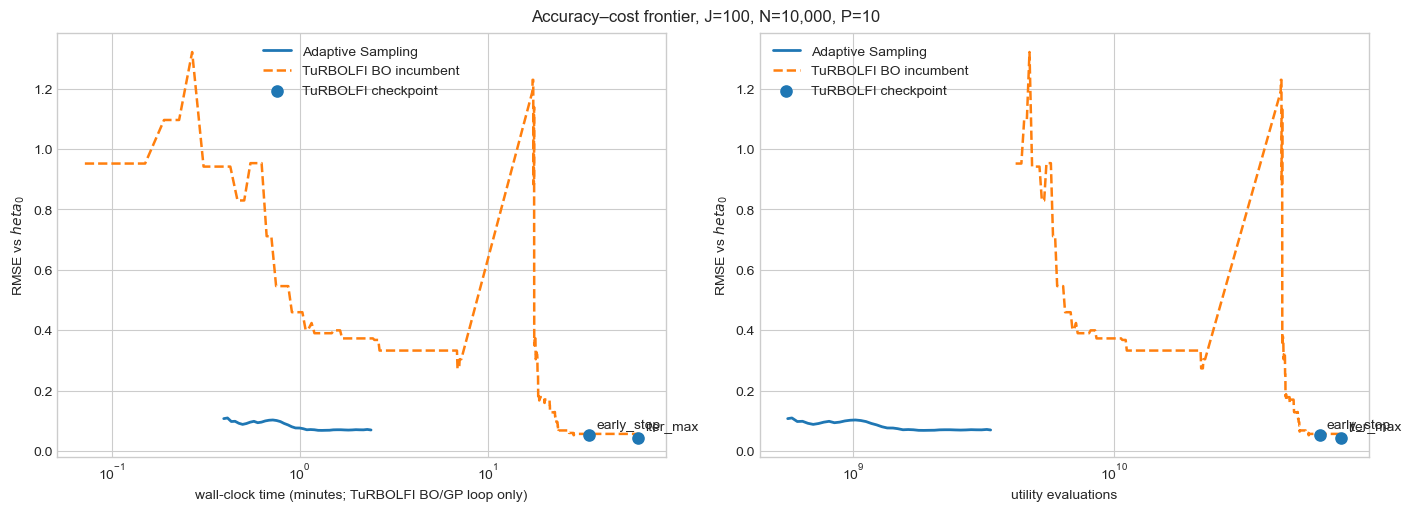

,minutes,method,rmse,utility_evals,checkpoint
0,1,Adaptive Sampling,0.075843,1.418480e+09,trajectory
1,1,TuRBOLFI BO incumbent,0.459592,6.700800e+09,trajectory
2,5,Adaptive Sampling,0.069364,3.360000e+09,trajectory
3,5,TuRBOLFI BO incumbent,0.332519,1.696560e+10,trajectory
4,15,Adaptive Sampling,0.069364,3.360000e+09,trajectory
5,15,TuRBOLFI BO incumbent,0.303862,2.231640e+10,trajectory
6,60,Adaptive Sampling,0.069364,3.360000e+09,trajectory
7,60,TuRBOLFI BO incumbent,0.056385,7.297980e+10,trajectory
8,60,TuRBOLFI posterior checkpoint,0.051952,6.127740e+10,early_stop


In [ ]:
# --- Choose the configuration for the single-configuration figure ---
J_PLOT = 100
N_PLOT = 10_000
P_PLOT = 10

# Validate that this configuration is available for both methods.
common = sorted(set(map(tuple, adaptive[['J','N','P']].drop_duplicates().values)) & set(map(tuple, turbo[['J','N','P']].drop_duplicates().values)))
if not common:
    raise ValueError('No shared J/N/P configuration. Add a timed Adaptive trace or choose matching TuRBOLFI artifacts.')
requested = (J_PLOT, N_PLOT, P_PLOT)
if requested not in common:
    raise ValueError(f'Requested {requested} is unavailable. Shared configurations: {common}')
J, N, P = requested
a = adaptive.query('J == @J and N == @N and P == @P').sort_values('wall_s')
t = turbo.query('J == @J and N == @N and P == @P')
b = turbo_incumbent.query('J == @J and N == @N and P == @P').sort_values('wall_s')
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for axis, cost, label in zip(axes, ['wall_s', 'utility_evals'], ['wall-clock time (minutes; TuRBOLFI BO/GP loop only)', 'utility evaluations']):
    x = a[cost] / 60 if cost == 'wall_s' else a[cost]
    xt = t[cost] / 60 if cost == 'wall_s' else t[cost]
    xb = b[cost] / 60 if cost == 'wall_s' else b[cost]
    axis.plot(x, a.rmse, label='Adaptive Sampling', lw=2)
    axis.plot(xb, b.rmse, '--', label='TuRBOLFI BO incumbent', lw=1.8)
    valid_t = t.dropna(subset=[cost])
    axis.scatter(xt.loc[valid_t.index], valid_t.rmse, label='TuRBOLFI checkpoint', s=65, zorder=3)
    for _, row in valid_t.iterrows(): axis.annotate(row.checkpoint, (row[cost] / 60 if cost == 'wall_s' else row[cost], row.rmse), xytext=(5, 5), textcoords='offset points')
    axis.set_xscale('log'); axis.set_xlabel(label); axis.set_ylabel('RMSE vs true value'); axis.legend()
fig.suptitle(f'Accuracy–cost frontier, J={J}, N={N:,}, P={P}')
plt.show()

# Exact values at the requested fixed wall-clock budgets.
table = []
for minutes in BUDGET_MINUTES:
    for method, frame in [('Adaptive Sampling', a), ('TuRBOLFI BO incumbent', b), ('TuRBOLFI posterior checkpoint', t)]:
        eligible = frame[frame.wall_s <= minutes * 60]
        if not eligible.empty:
            row = eligible.iloc[-1]
            table.append(dict(minutes=minutes, method=method, rmse=row.rmse, utility_evals=row.utility_evals, checkpoint=row.get('checkpoint', 'trajectory')))
pd.DataFrame(table)

## All-configuration accuracy–cost frontier

Each colour denotes one $(J,N)$ configuration. Solid lines are Adaptive Sampling; dashed lines are the RMSE of TuRBOLFI's best BO-evaluated point (the incumbent) at every iteration; circles are the available TuRBOLFI posterior checkpoints. The incumbent is not a posterior mean. The wall-clock values for TuRBOLFI are BO/GP-loop time only—the same convention as `MLBA_timecost`—and exclude its initial design and posterior MCMC.

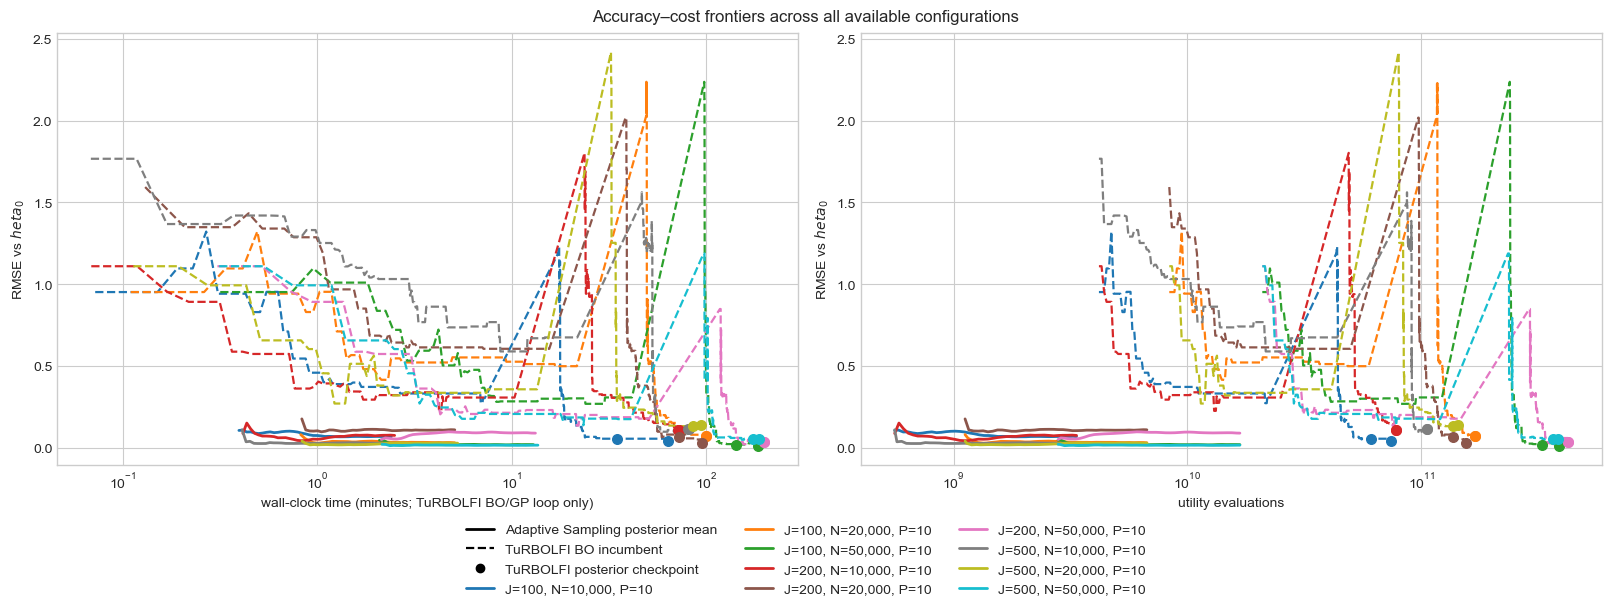

In [5]:
from matplotlib.lines import Line2D

config_columns = ['J', 'N', 'P']
configs = sorted(set(map(tuple, adaptive[config_columns].drop_duplicates().values)) | set(map(tuple, turbo[config_columns].drop_duplicates().values)))
if not configs:
    raise ValueError('No Adaptive or TuRBOLFI frontier rows are available.')
colours = plt.get_cmap('tab10')(np.linspace(0, 1, len(configs)))
colour_for = dict(zip(configs, colours))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
for axis, cost, xlabel in zip(axes, ['wall_s', 'utility_evals'], ['wall-clock time (minutes; TuRBOLFI BO/GP loop only)', 'utility evaluations']):
    for cfg in configs:
        J, N, P = cfg
        colour = colour_for[cfg]
        a_cfg = adaptive.query('J == @J and N == @N and P == @P').sort_values(cost)
        b_cfg = turbo_incumbent.query('J == @J and N == @N and P == @P').sort_values(cost)
        t_cfg = turbo.query('J == @J and N == @N and P == @P').dropna(subset=[cost]).sort_values(cost)
        if not a_cfg.empty:
            x = a_cfg[cost] / 60 if cost == 'wall_s' else a_cfg[cost]
            axis.plot(x, a_cfg.rmse, color=colour, lw=2)
        if not b_cfg.empty:
            x = b_cfg[cost] / 60 if cost == 'wall_s' else b_cfg[cost]
            axis.plot(x, b_cfg.rmse, color=colour, lw=1.6, ls='--')
        if not t_cfg.empty:
            x = t_cfg[cost] / 60 if cost == 'wall_s' else t_cfg[cost]
            axis.scatter(x, t_cfg.rmse, color=colour, marker='o', s=48, zorder=3)
    axis.set_xscale('log')
    axis.set_xlabel(xlabel)
    axis.set_ylabel('RMSE vs $\theta_0$')

config_handles = [Line2D([0], [0], color=colour_for[cfg], lw=2, label=f'J={cfg[0]}, N={cfg[1]:,}, P={cfg[2]}') for cfg in configs]
method_handles = [Line2D([0], [0], color='black', lw=2, label='Adaptive Sampling posterior mean'), Line2D([0], [0], color='black', lw=1.6, ls='--', label='TuRBOLFI BO incumbent'), Line2D([0], [0], color='black', marker='o', lw=0, label='TuRBOLFI posterior checkpoint')]
fig.legend(handles=method_handles + config_handles, loc='outside lower center', ncol=3, frameon=False)
fig.suptitle('Accuracy–cost frontiers across all available configurations')
plt.show()

## What remains for the strongest figure

To turn the two TuRBOLFI points into a line, rerun `gp_retrive` and `MCMC_sampling` for a prespecified set of BO point counts (for example the counts first reached at 1, 5, 15, and 60 minutes). Save each trace as `MCMC_trace_budget_<count>.nc` and extend `turbo_checkpoints`. For a later end-to-end wall-clock analysis, also record the posterior-MCMC elapsed seconds. Keep the same data seed, GP/likelihood settings, and MCMC draws/tuning.

For ribbons across simulated datasets, repeat each configuration with multiple data seeds and store a seed identifier in the filename. Aggregate the resulting RMSEs at common budgets with their median and 10–90% (or bootstrap 95%) interval. Do not use the currently available cross-configuration grid as a ribbon: changing $J$ or $N$ changes the statistical problem rather than just simulation noise.